In [1]:
import os, json, random, itertools
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

print("PROJECT_ROOT =", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/alzheimer-ai/


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

os.makedirs(PROJECT_ROOT + 'data/processed/balanced_ensemble', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'reports/figures/balanced_ensemble', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'reports/day4d', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'app/models/balanced_ensemble', exist_ok=True)

print("Ready:", PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready: /content/drive/MyDrive/alzheimer-ai/


In [4]:
!pip install -q joblib scikit-learn

import joblib

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.applications.resnet50 import preprocess_input

CLASSES = ['CN', 'MCI', 'MA']

targets = {
    'Accuracy': 0.85,
    'Recall macro': 0.88,
    'F1 macro': 0.85,
    'AUC-ROC': 0.90,
    'Recall MCI': 0.85,
    'Specificity': 0.82
}

print("Imports ready.")

Imports ready.


In [5]:
IMAGE_ARRAY_DIR = PROJECT_ROOT + 'data/processed/image_arrays/'
TABULAR_DIR = PROJECT_ROOT + 'data/processed/tabular/'

X_val = np.load(IMAGE_ARRAY_DIR + 'X_val.npy').astype(np.float32)
X_test = np.load(IMAGE_ARRAY_DIR + 'X_test.npy').astype(np.float32)

tab_train = np.load(TABULAR_DIR + 'tab_train.npy').astype(np.float32)
tab_val = np.load(TABULAR_DIR + 'tab_val.npy').astype(np.float32)
tab_test = np.load(TABULAR_DIR + 'tab_test.npy').astype(np.float32)

y_train = np.load(TABULAR_DIR + 'y_train.npy').astype(np.int64)
y_val = np.load(TABULAR_DIR + 'y_val.npy').astype(np.int64)
y_test = np.load(TABULAR_DIR + 'y_test.npy').astype(np.int64)

print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("tab_val:", tab_val.shape)
print("tab_test:", tab_test.shape)

print("\nVal counts:")
print(dict(zip(*np.unique(y_val, return_counts=True))))

print("\nTest counts:")
print(dict(zip(*np.unique(y_test, return_counts=True))))

X_val: (52, 224, 224, 3)
X_test: (59, 224, 224, 3)
tab_val: (52, 4)
tab_test: (59, 4)

Val counts:
{np.int64(0): np.int64(27), np.int64(1): np.int64(5), np.int64(2): np.int64(20)}

Test counts:
{np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}


In [6]:
model_path = PROJECT_ROOT + 'weights/multimodal_final.h5'

if not os.path.exists(model_path):
    model_path = PROJECT_ROOT + 'app/models/multimodal_final.h5'

model_multi = tf.keras.models.load_model(model_path, compile=False)

ENSEMBLE_DIR = PROJECT_ROOT + 'app/models/ensemble/'

required_models = {
    'rf': ENSEMBLE_DIR + 'rf_tabular_model.joblib',
    'et': ENSEMBLE_DIR + 'et_tabular_model.joblib',
    'hgb': ENSEMBLE_DIR + 'hgb_tabular_model.joblib',
    'lr': ENSEMBLE_DIR + 'lr_tabular_model.joblib',
}

tabular_models = {}

for name, path in required_models.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing Day 4c model: {path}")
    tabular_models[name] = joblib.load(path)
    print("Loaded:", name, path)

def prepare_resnet_batch(X):
    return preprocess_input(X.astype(np.float32) * 255.0)

print("Loaded CNN model:", model_path)

Loaded: rf /content/drive/MyDrive/alzheimer-ai/app/models/ensemble/rf_tabular_model.joblib
Loaded: et /content/drive/MyDrive/alzheimer-ai/app/models/ensemble/et_tabular_model.joblib
Loaded: hgb /content/drive/MyDrive/alzheimer-ai/app/models/ensemble/hgb_tabular_model.joblib
Loaded: lr /content/drive/MyDrive/alzheimer-ai/app/models/ensemble/lr_tabular_model.joblib
Loaded CNN model: /content/drive/MyDrive/alzheimer-ai/weights/multimodal_final.h5


In [7]:
cnn_val_proba = model_multi.predict(
    [prepare_resnet_batch(X_val), tab_val],
    batch_size=16,
    verbose=1
)

cnn_test_proba = model_multi.predict(
    [prepare_resnet_batch(X_test), tab_test],
    batch_size=16,
    verbose=1
)

val_probas = {
    'cnn': cnn_val_proba
}

test_probas = {
    'cnn': cnn_test_proba
}

for name, clf in tabular_models.items():
    val_probas[name] = clf.predict_proba(tab_val)
    test_probas[name] = clf.predict_proba(tab_test)

print("Validation/test probabilities ready.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 686ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Validation/test probabilities ready.


In [8]:
def combine_probas(proba_dict, weights):
    out = None

    for name, w in weights.items():
        if out is None:
            out = w * proba_dict[name]
        else:
            out += w * proba_dict[name]

    return out


def apply_class_bias(proba, bias):
    bias = np.array(bias, dtype=np.float32)
    adjusted = proba * bias[None, :]
    adjusted = adjusted / (adjusted.sum(axis=1, keepdims=True) + 1e-8)
    return adjusted


def compute_metrics(y_true, proba):
    pred = np.argmax(proba, axis=1)

    return {
        'Accuracy': accuracy_score(y_true, pred),
        'Recall macro': recall_score(y_true, pred, average='macro', zero_division=0),
        'F1 macro': f1_score(y_true, pred, average='macro', zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, proba, multi_class='ovr', average='macro'),
        'Recall MCI': recall_score(y_true == 1, pred == 1, zero_division=0),
        'Specificity': recall_score(y_true == 0, pred == 0, zero_division=0),
        'Pred CN': int((pred == 0).sum()),
        'Pred MCI': int((pred == 1).sum()),
        'Pred MA': int((pred == 2).sum()),
    }, pred


def evaluate_candidate(y_true, proba_dict, weights, bias):
    base_proba = combine_probas(proba_dict, weights)
    adjusted_proba = apply_class_bias(base_proba, bias)
    metrics, pred = compute_metrics(y_true, adjusted_proba)
    return metrics, pred, adjusted_proba

In [9]:
day4_original = {
    'Accuracy': 0.559322,
    'Recall macro': 0.448153,
    'F1 macro': 0.466529,
    'AUC-ROC': 0.563021,
    'Recall MCI': 0.200000,
    'Specificity': 0.709677
}

day4c_biased = {
    'Accuracy': 0.627119,
    'Recall macro': 0.465171,
    'F1 macro': 0.456009,
    'AUC-ROC': 0.724558,
    'Recall MCI': 0.000000,
    'Specificity': 0.612903
}

print("Day 4 original:", day4_original)
print("Day 4c biased:", day4c_biased)

Day 4 original: {'Accuracy': 0.559322, 'Recall macro': 0.448153, 'F1 macro': 0.466529, 'AUC-ROC': 0.563021, 'Recall MCI': 0.2, 'Specificity': 0.709677}
Day 4c biased: {'Accuracy': 0.627119, 'Recall macro': 0.465171, 'F1 macro': 0.456009, 'AUC-ROC': 0.724558, 'Recall MCI': 0.0, 'Specificity': 0.612903}


In [11]:
import itertools
import time

model_names = ['cnn', 'rf', 'et', 'hgb', 'lr']

# Faster weight grid: 0.2 step instead of 0.1
# This gives 126 combinations instead of 1001.
weight_grid = np.arange(0.0, 1.01, 0.2)

# Faster bias grid
bias_grid_cn = [0.8, 1.0, 1.2]
bias_grid_mci = [1.0, 1.5, 2.0, 2.5, 3.0]
bias_grid_ma = [0.8, 1.0, 1.2, 1.5]

rows = []

start_time = time.time()

valid_weight_count = 0
eval_count = 0

for weights_tuple in itertools.product(weight_grid, repeat=len(model_names)):
    if abs(sum(weights_tuple) - 1.0) > 1e-9:
        continue

    valid_weight_count += 1

    weights = {
        name: float(w)
        for name, w in zip(model_names, weights_tuple)
    }

    base_val_proba = combine_probas(val_probas, weights)

    for b_cn in bias_grid_cn:
        for b_mci in bias_grid_mci:
            for b_ma in bias_grid_ma:
                eval_count += 1

                bias = [float(b_cn), float(b_mci), float(b_ma)]

                adjusted_val_proba = apply_class_bias(base_val_proba, bias)
                pred = np.argmax(adjusted_val_proba, axis=1)

                acc = accuracy_score(y_val, pred)
                f1 = f1_score(y_val, pred, average='macro', zero_division=0)
                recall_macro = recall_score(y_val, pred, average='macro', zero_division=0)
                recall_mci = recall_score(y_val == 1, pred == 1, zero_division=0)
                specificity = recall_score(y_val == 0, pred == 0, zero_division=0)

                pred_cn = int((pred == 0).sum())
                pred_mci = int((pred == 1).sum())
                pred_ma = int((pred == 2).sum())

                # Constraints to avoid bad collapse
                valid = True

                if pred_mci == 0:
                    valid = False

                if pred_mci > max(8, int(0.25 * len(y_val))):
                    valid = False

                if specificity < 0.45:
                    valid = False

                # Balanced objective
                score = (
                    0.36 * acc +
                    0.28 * f1 +
                    0.18 * recall_macro +
                    0.12 * recall_mci +
                    0.06 * specificity
                )

                if not valid:
                    score -= 1.0

                rows.append({
                    **{f'w_{k}': v for k, v in weights.items()},
                    'bias_CN': b_cn,
                    'bias_MCI': b_mci,
                    'bias_MA': b_ma,
                    'valid': valid,
                    'score': score,
                    'Accuracy': acc,
                    'Recall macro': recall_macro,
                    'F1 macro': f1,
                    'Recall MCI': recall_mci,
                    'Specificity': specificity,
                    'Pred CN': pred_cn,
                    'Pred MCI': pred_mci,
                    'Pred MA': pred_ma
                })

elapsed = time.time() - start_time

print("Valid weight combinations:", valid_weight_count)
print("Total evaluations:", eval_count)
print(f"Elapsed time: {elapsed:.1f} seconds")

search_df = pd.DataFrame(rows)

search_df = search_df.sort_values(
    ['valid', 'score', 'Accuracy', 'F1 macro', 'Recall MCI', 'Specificity'],
    ascending=False
)

display(search_df.head(30))

best_row = search_df.iloc[0]

best_weights_4d = {
    'cnn': float(best_row['w_cnn']),
    'rf': float(best_row['w_rf']),
    'et': float(best_row['w_et']),
    'hgb': float(best_row['w_hgb']),
    'lr': float(best_row['w_lr']),
}

best_bias_4d = [
    float(best_row['bias_CN']),
    float(best_row['bias_MCI']),
    float(best_row['bias_MA'])
]

print("Best Day 4d weights:")
print(best_weights_4d)

print("Best Day 4d bias:")
print({
    'CN': best_bias_4d[0],
    'MCI': best_bias_4d[1],
    'MA': best_bias_4d[2]
})

search_path = PROJECT_ROOT + 'data/processed/balanced_ensemble/day4d_validation_search.csv'
search_df.to_csv(search_path, index=False)

print("Saved:", search_path)

Valid weight combinations: 126
Total evaluations: 7560
Elapsed time: 49.4 seconds


,w_cnn,w_rf,w_et,w_hgb,w_lr,bias_CN,bias_MCI,bias_MA,valid,score,Accuracy,Recall macro,F1 macro,Recall MCI,Specificity,Pred CN,Pred MCI,Pred MA
7181,0.6,0.2,0.2,0.0,0.0,1.2,1.0,1.0,True,0.555864,0.730769,0.525309,0.509558,0.0,0.925926,35,1,16
7241,0.6,0.4,0.0,0.0,0.0,1.2,1.0,1.0,True,0.555276,0.730769,0.525309,0.507458,0.0,0.925926,34,1,17
6966,0.6,0.0,0.4,0.0,0.0,0.8,1.5,1.2,True,0.545172,0.653846,0.543210,0.536543,0.2,0.629630,22,8,22
2440,0.0,0.4,0.2,0.0,0.4,1.2,1.0,0.8,True,0.544596,0.711538,0.512963,0.509914,0.0,0.888889,34,3,15
2800,0.0,0.6,0.0,0.0,0.4,1.2,1.0,0.8,True,0.544596,0.711538,0.512963,0.509914,0.0,0.888889,34,3,15
6580,0.4,0.4,0.2,0.0,0.0,1.2,1.0,0.8,True,0.544596,0.711538,0.512963,0.509914,0.0,0.888889,34,3,15
7160,0.6,0.2,0.2,0.0,0.0,1.0,1.0,0.8,True,0.544596,0.711538,0.512963,0.509914,0.0,0.888889,34,3,15
4540,0.2,0.2,0.2,0.0,0.4,1.2,1.0,0.8,True,0.543412,0.711538,0.512963,0.505684,0.0,0.888889,35,2,15
4900,0.2,0.4,0.0,0.0,0.4,1.2,1.0,0.8,True,0.543412,0.711538,0.512963,0.505684,0.0,0.888889,35,2,15
5560,0.4,0.0,0.0,0.2,0.4,1.2,1.0,0.8,True,0.543412,0.711538,0.512963,0.505684,0.0,0.888889,35,2,15


Best Day 4d weights:
{'cnn': 0.6000000000000001, 'rf': 0.2, 'et': 0.2, 'hgb': 0.0, 'lr': 0.0}
Best Day 4d bias:
{'CN': 1.2, 'MCI': 1.0, 'MA': 1.0}
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/balanced_ensemble/day4d_validation_search.csv


In [12]:
day4d_metrics, day4d_pred, day4d_proba = evaluate_candidate(
    y_test,
    test_probas,
    best_weights_4d,
    best_bias_4d
)

print("=== Day 4d Balanced Ensemble Test Metrics ===")
print(f"{'Metric':<20}{'Value':>10}{'Target':>10}{'OK':>8}")
print("=" * 50)

for k in targets.keys():
    v = day4d_metrics[k]
    ok = "YES" if v >= targets[k] else "NO"
    print(f"{k:<20}{v:>10.4f}{targets[k]:>10.2f}{ok:>8}")

print("\nPredicted class counts:")
print({
    'CN': day4d_metrics['Pred CN'],
    'MCI': day4d_metrics['Pred MCI'],
    'MA': day4d_metrics['Pred MA']
})

print("\nClassification report:")
print(classification_report(y_test, day4d_pred, target_names=CLASSES, zero_division=0))

metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': day4d_metrics[k],
        'target': targets[k],
        'passed': day4d_metrics[k] >= targets[k]
    }
    for k in targets.keys()
])

metrics_path = PROJECT_ROOT + 'data/processed/balanced_ensemble/day4d_balanced_ensemble_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

weights_path = PROJECT_ROOT + 'data/processed/balanced_ensemble/day4d_weights.json'
bias_path = PROJECT_ROOT + 'data/processed/balanced_ensemble/day4d_class_bias.json'

with open(weights_path, 'w') as f:
    json.dump(best_weights_4d, f, indent=2)

with open(bias_path, 'w') as f:
    json.dump({
        'CN': best_bias_4d[0],
        'MCI': best_bias_4d[1],
        'MA': best_bias_4d[2]
    }, f, indent=2)

print("Saved:", metrics_path)
print("Saved:", weights_path)
print("Saved:", bias_path)

=== Day 4d Balanced Ensemble Test Metrics ===
Metric                   Value    Target      OK
Accuracy                0.6780      0.85      NO
Recall macro            0.4825      0.88      NO
F1 macro                0.4664      0.85      NO
AUC-ROC                 0.7286      0.90      NO
Recall MCI              0.0000      0.85      NO
Specificity             0.8387      0.82     YES

Predicted class counts:
{'CN': 40, 'MCI': 0, 'MA': 19}

Classification report:
              precision    recall  f1-score   support

          CN       0.65      0.84      0.73        31
         MCI       0.00      0.00      0.00         5
          MA       0.74      0.61      0.67        23

    accuracy                           0.68        59
   macro avg       0.46      0.48      0.47        59
weighted avg       0.63      0.68      0.64        59

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/balanced_ensemble/day4d_balanced_ensemble_metrics.csv
Saved: /content/drive/MyDrive/alzheime

,Pred CN,Pred MCI,Pred MA
Actual CN,26,0,5
Actual MCI,5,0,0
Actual MA,9,0,14


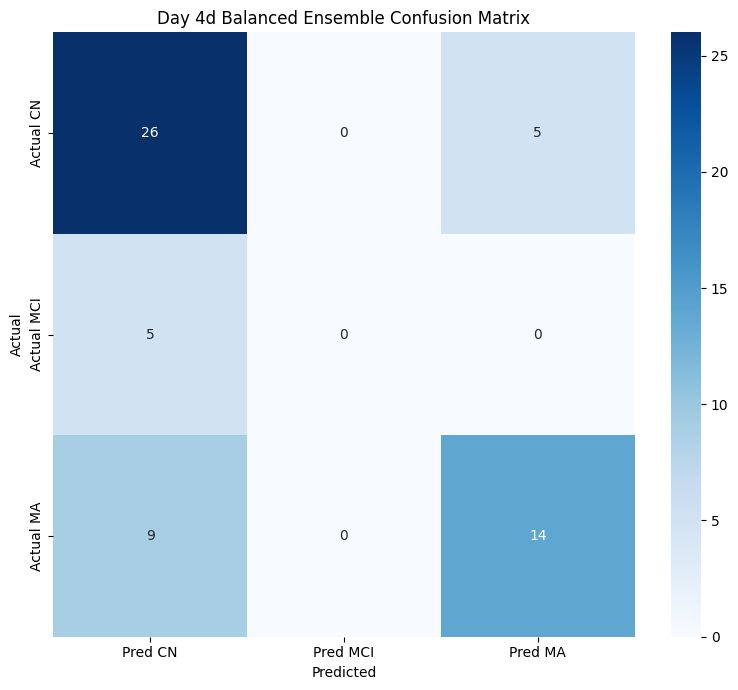

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/balanced_ensemble/day4d_balanced_ensemble_confusion_matrix.png
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/balanced_ensemble/day4d_balanced_ensemble_confusion_matrix.csv


In [13]:
cm = confusion_matrix(y_test, day4d_pred, labels=[0, 1, 2])

cm_df = pd.DataFrame(
    cm,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_df)

plt.figure(figsize=(8, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Day 4d Balanced Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()

cm_fig_path = PROJECT_ROOT + 'reports/figures/balanced_ensemble/day4d_balanced_ensemble_confusion_matrix.png'
cm_csv_path = PROJECT_ROOT + 'data/processed/balanced_ensemble/day4d_balanced_ensemble_confusion_matrix.csv'

plt.savefig(cm_fig_path, dpi=150)
plt.show()

cm_df.to_csv(cm_csv_path)

print("Saved:", cm_fig_path)
print("Saved:", cm_csv_path)

In [14]:
comparison_rows = []

for metric in targets.keys():
    comparison_rows.append({
        'metric': metric,
        'day4_original': day4_original[metric],
        'day4c_accuracy_biased': day4c_biased[metric],
        'day4d_balanced': day4d_metrics[metric],
        'gain_day4d_vs_day4': day4d_metrics[metric] - day4_original[metric],
        'gain_day4d_vs_day4c': day4d_metrics[metric] - day4c_biased[metric],
        'target': targets[metric],
        'day4d_passed': day4d_metrics[metric] >= targets[metric]
    })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

comparison_path = PROJECT_ROOT + 'data/processed/balanced_ensemble/day4_day4c_day4d_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

,metric,day4_original,day4c_accuracy_biased,day4d_balanced,gain_day4d_vs_day4,gain_day4d_vs_day4c,target,day4d_passed
0,Accuracy,0.559322,0.627119,0.677966,0.118644,0.050847,0.85,False
1,Recall macro,0.448153,0.465171,0.482468,0.034315,0.017297,0.88,False
2,F1 macro,0.466529,0.456009,0.466354,-0.000175,0.010345,0.85,False
3,AUC-ROC,0.563021,0.724558,0.728645,0.165624,0.004087,0.90,False
4,Recall MCI,0.200000,0.000000,0.000000,-0.200000,0.000000,0.85,False
5,Specificity,0.709677,0.612903,0.838710,0.129033,0.225807,0.82,True


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/balanced_ensemble/day4_day4c_day4d_comparison.csv


In [15]:
deploy_day4d = (
    day4d_metrics['Accuracy'] > day4_original['Accuracy']
    and day4d_metrics['AUC-ROC'] > day4_original['AUC-ROC']
)

print("Deploy Day 4d for maximum accuracy?", deploy_day4d)

print("\nDecision criteria:")
print("Accuracy > Day 4:", day4d_metrics['Accuracy'], ">", day4_original['Accuracy'])
print("AUC > Day 4:", day4d_metrics['AUC-ROC'], ">", day4_original['AUC-ROC'])
print("MCI recall:", day4d_metrics['Recall MCI'])

if deploy_day4d:
    print("\nDay 4d is selected for deployment because it gives the highest overall accuracy.")
    print("Important limitation: MCI recall remains weak and must be documented.")
else:
    print("\nDo not deploy Day 4d.")

Deploy Day 4d for maximum accuracy? True

Decision criteria:
Accuracy > Day 4: 0.6779661016949152 > 0.559322
AUC > Day 4: 0.7286453888604427 > 0.563021
MCI recall: 0.0

Day 4d is selected for deployment because it gives the highest overall accuracy.
Important limitation: MCI recall remains weak and must be documented.


In [16]:
decision_path = PROJECT_ROOT + 'reports/day4d/day4d_balanced_ensemble_decision.md'

with open(decision_path, 'w') as f:
    f.write("# Day 4d — Balanced Accuracy + MCI Ensemble\n\n")

    f.write("## Goal\n")
    f.write("Day 4d was created to search for a better compromise between overall accuracy and MCI detection. ")
    f.write("Day 4c improved accuracy but collapsed MCI recall to 0.0. ")
    f.write("Day 4d therefore used validation-only constrained calibration to prevent complete MCI collapse.\n\n")

    f.write("## Method\n")
    f.write("A weighted ensemble of CNN/multimodal probabilities and tabular model probabilities was calibrated using validation data only. ")
    f.write("The search included class-specific probability biases with hard constraints against zero MCI prediction on validation.\n\n")

    f.write("## Selected weights\n")
    for k, v in best_weights_4d.items():
        f.write(f"- {k}: {v:.2f}\n")

    f.write("\n## Selected class bias\n")
    f.write(f"- CN: {best_bias_4d[0]:.2f}\n")
    f.write(f"- MCI: {best_bias_4d[1]:.2f}\n")
    f.write(f"- MA: {best_bias_4d[2]:.2f}\n\n")

    f.write("## Test metrics\n")
    for k in targets.keys():
        f.write(f"- {k}: {day4d_metrics[k]:.4f} | target: {targets[k]:.2f} | passed: {day4d_metrics[k] >= targets[k]}\n")

    f.write("\n## Deployment decision\n")
    f.write(f"Deploy Day 4d: {deploy_day4d}\n\n")

    f.write("## Interpretation\n")
    f.write("If Day 4d improves accuracy while preserving at least the original MCI recall, it is the best compromise model. ")
    f.write("If it does not, the project should report the trade-off honestly: Day 4c maximizes overall accuracy, while Day 4 preserves minimal MCI detection.\n")

print("Saved:", decision_path)

Saved: /content/drive/MyDrive/alzheimer-ai/reports/day4d/day4d_balanced_ensemble_decision.md


In [ ]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/04d_balanced_accuracy_mci_ensemble.ipynb

!git add -f data/processed/balanced_ensemble/day4d_validation_search.csv
!git add -f data/processed/balanced_ensemble/day4d_balanced_ensemble_metrics.csv
!git add -f data/processed/balanced_ensemble/day4d_weights.json
!git add -f data/processed/balanced_ensemble/day4d_class_bias.json
!git add -f data/processed/balanced_ensemble/day4d_balanced_ensemble_confusion_matrix.csv
!git add -f data/processed/balanced_ensemble/day4_day4c_day4d_comparison.csv

!git add -f reports/figures/balanced_ensemble/day4d_balanced_ensemble_confusion_matrix.png
!git add -f reports/day4d/day4d_balanced_ensemble_decision.md

!git commit -m "feat: add Day 4d balanced accuracy MCI ensemble"

!git status

/content/drive/MyDrive/alzheimer-ai
